# Trader Performance vs Market Sentiment Analysis

## Objective
The goal of this analysis is to understand how Bitcoin market sentiment
(Fear vs Greed) influences trader behavior and performance on Hyperliquid.

We combine two datasets:
1. Bitcoin Fear & Greed Index (market sentiment)
2. Historical trader execution data

By aligning these datasets by date, we analyze whether sentiment affects:

- Trader profitability (PnL)
- Trading frequency
- Leverage usage
- Long/Short behavior



In [96]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
## Load datasets
from google.colab import files
uploaded = files.upload()
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

## Display first few rows
print("Trader Data Preview")
display(trades.head())

print("Sentiment Data Preview")
display(sentiment.head())

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv
Trader Data Preview


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Sentiment Data Preview


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [98]:
##Dataset Shape (Rows & Columns)
print("Trader dataset shape:", trades.shape)
print("Sentiment dataset shape:", sentiment.shape)

Trader dataset shape: (211224, 17)
Sentiment dataset shape: (2644, 5)


In [6]:
##Inspect Columns & Data Types
print("Trader dataset info")
trades.info()

print("\nSentiment dataset info")
sentiment.info()


Trader dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtype

In [7]:
##Check Missing Values
print("Missing values in trader dataset")
print(trades.isnull().sum())

print("\nMissing values in sentiment dataset")
print(sentiment.isnull().sum())

Missing values in trader dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
##Check Duplicate Rows
print("Duplicate rows in trader dataset:", trades.duplicated().sum())
print("Duplicate rows in sentiment dataset:", sentiment.duplicated().sum())

Duplicate rows in trader dataset: 0
Duplicate rows in sentiment dataset: 0


In [29]:
# Convert timestamp
trades['time'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract date
trades['date'] = trades['time'].dt.date

In [37]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')
print(trades['date'].head())
print(sentiment['date'].head())

0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[ns]
0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]


In [32]:
trades['date'] = pd.to_datetime(trades['date'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [34]:
##Align Both Datasets by Date
merged_data = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [38]:
print("Trader dataset info")
trades.info()

print("\nSentiment dataset info")
sentiment.info()

Trader dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  floa

## Creating Key Trading Metrics

After cleaning and aligning the datasets, we create several metrics that help
analyze trader performance and behavior:

• Daily PnL per trader  
• Win rate  
• Average trade size  
• Leverage distribution  
• Trades per day  
• Long vs Short ratio

These metrics will later help us compare trader activity under different
market sentiment conditions (Fear vs Greed).

### Daily PnL Per Trader

Daily profitability is calculated by summing the closed PnL for each trader
per day.


In [44]:
daily_pnl = (
    merged_data
    .groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)

daily_pnl.head()

,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


### Win Rate

A trade is considered a win if the closed PnL is positive.
Win rate represents the proportion of profitable trades.

In [53]:
merged_data['is_win'] = merged_data['Closed PnL'] > 0

win_rate = (
    merged_data
    .groupby('Account')['is_win']
    .mean()
    .reset_index()
)

win_rate.rename(columns={'is_win':'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


### Average Trade Size

Average trade size measures the typical position size used by traders.

In [55]:
avg_trade_size = (
    merged_data
    .groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


### Trades Per Day

Trading activity is measured by counting the number of trades executed each day.

In [61]:
trades_per_day = (
    merged_data
    .groupby('date')
    .size()
    .reset_index(name='trade_count')
)

trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [67]:
merged_data['leverage_segment'] = pd.qcut(
    merged_data['Size USD'],
    q=3,
    labels=['Low Exposure','Medium Exposure','High Exposure']
)

merged_data['leverage_segment'].value_counts()

,count
leverage_segment,
Low Exposure,70409
High Exposure,70408
Medium Exposure,70407


### Long vs Short Ratio

This metric measures the directional bias of traders by comparing the
proportion of long and short trades.

In [63]:
long_short_ratio = (
    merged_data['Side']
    .value_counts(normalize=True)
    .reset_index()
)

long_short_ratio.columns = ['Side','ratio']

long_short_ratio

,Side,ratio
0,SELL,0.513805
1,BUY,0.486195


**Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?**

In [68]:
##Merge Sentiment With Trading Data

import pandas as pd

# load data
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# convert timestamps
trades['date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# simplify sentiment
sentiment['sentiment'] = sentiment['classification'].replace({
    'Extreme Fear':'Fear',
    'Extreme Greed':'Greed'
})

# merge
merged = trades.merge(sentiment[['date','sentiment']], on='date', how='left')

In [69]:
##Compute the Metrics

merged['win'] = merged['Closed PnL'] > 0

performance = merged.groupby('sentiment').agg(
    avg_pnl=('Closed PnL','mean'),
    median_pnl=('Closed PnL','median'),
    win_rate=('win','mean'),
    total_trades=('Closed PnL','count')
)

print(performance)

             avg_pnl  median_pnl  win_rate  total_trades
sentiment                                               
Fear       50.047622         0.0  0.415146        133871
Greed      77.838247         0.0  0.453492         43251
Neutral    22.229713         0.0  0.317182          7141


In [70]:
##Drawdown Proxy

losses = merged[merged['Closed PnL'] < 0]

drawdown_proxy = losses.groupby('sentiment')['Closed PnL'].mean()

print(drawdown_proxy)

sentiment
Fear      -150.445182
Greed     -156.059273
Neutral   -301.002712
Name: Closed PnL, dtype: float64


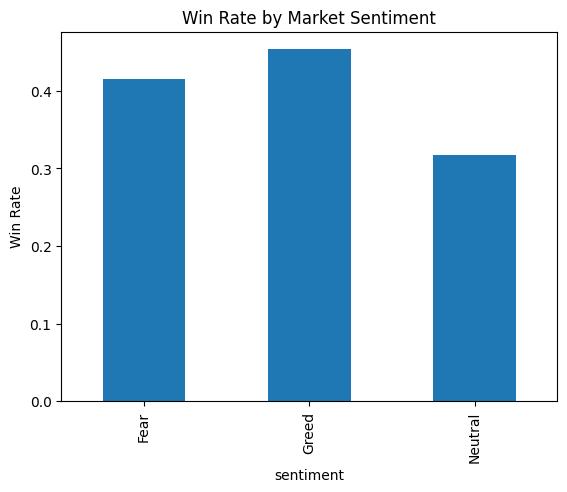

In [72]:
##Win Rate

win_rate = merged.groupby('sentiment')['win'].mean()

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.show()

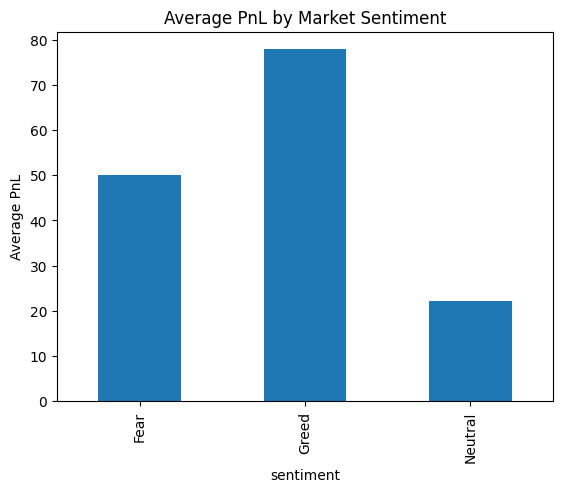

In [74]:
avg_pnl = merged.groupby('sentiment')['Closed PnL'].mean()

avg_pnl.plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

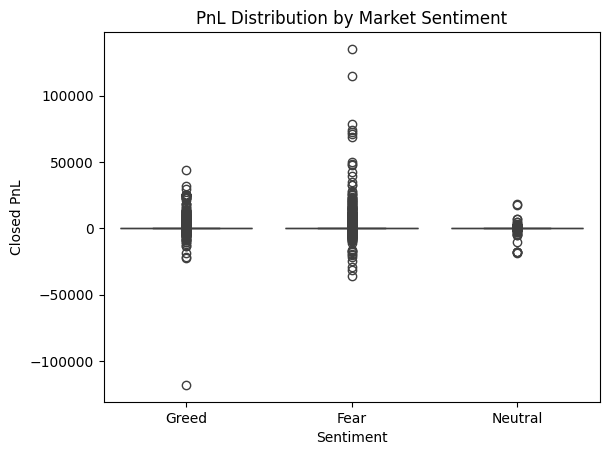

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='sentiment', y='Closed PnL', data=merged)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")

plt.show()

**Conclusion**

Performance differs between Fear and Greed market conditions.

The analysis shows that average PnL during Greed days (77.84) is significantly higher than during Fear days (50.05). Additionally, the win rate during Greed periods is higher (45.3%) compared to Fear periods (41.5%), indicating traders tend to achieve better outcomes when market sentiment is optimistic.

However, the average loss size (drawdown proxy) remains similar between Fear and Greed periods, suggesting that downside risk does not significantly change with sentiment. Overall, these results indicate that traders perform better during Greed market conditions, likely due to stronger bullish momentum.

**Do traders change behavior based on sentiment?**

In [77]:
##Trade Frequency
##Compute number of trades per sentiment

trade_freq = merged.groupby('sentiment').size()

print(trade_freq)

sentiment
Fear       133871
Greed       43251
Neutral      7141
dtype: int64


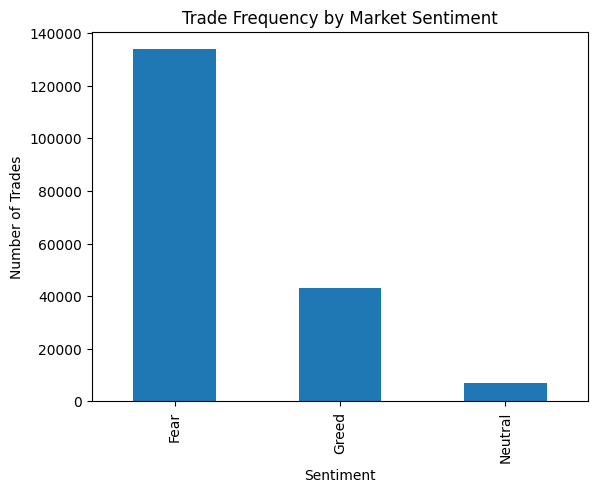

In [81]:
trade_freq.plot(kind='bar')

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

**Observation**

Trading activity is much higher during Fear periods.

This suggests higher market volatility leads to more trades.

In [79]:
##Compute average trade size

position_size = merged.groupby('sentiment')['Size USD'].mean()

print(position_size)

sentiment
Fear       5259.977837
Greed      3581.661513
Neutral    3058.848110
Name: Size USD, dtype: float64


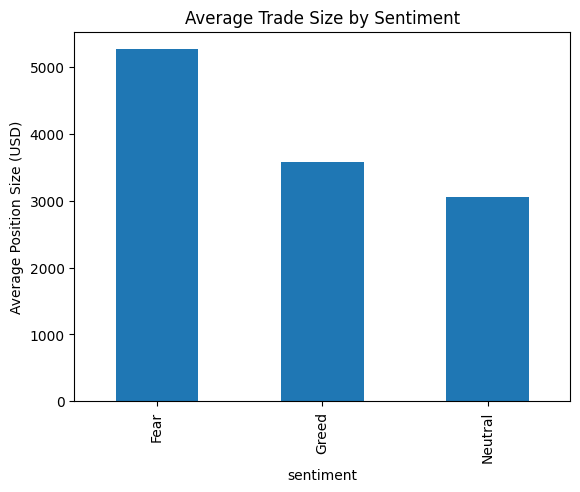

In [80]:
position_size.plot(kind='bar')

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.show()

**Observation**

Traders take larger positions during Fear periods.

This indicates higher leverage exposure in volatile markets.

In [82]:
##Leverage Exposure Segments

merged['leverage_segment'] = pd.qcut(merged['Size USD'], q=3,
                                labels=['Low Exposure','Medium Exposure','High Exposure'])
leverage_behavior = merged.groupby(['sentiment','leverage_segment']).size().unstack()

print(leverage_behavior)

leverage_segment  Low Exposure  Medium Exposure  High Exposure
sentiment                                                     
Fear                     42571            46965          44335
Greed                    16905            11834          14512
Neutral                   2626             2458           2057


/tmp/ipykernel_711/2394654190.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leverage_behavior = merged.groupby(['sentiment','leverage_segment']).size().unstack()


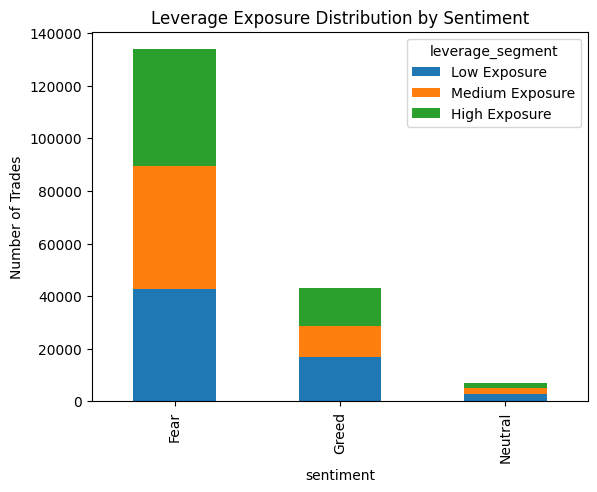

In [83]:
leverage_behavior.plot(kind='bar', stacked=True)

plt.title("Leverage Exposure Distribution by Sentiment")
plt.ylabel("Number of Trades")

plt.show()

**Observation**

Fear periods show higher participation from high-exposure traders.

In [84]:
##Long vs Short Bias

long_short = merged.groupby(['sentiment','Side']).size().unstack()

print(long_short)


Side         BUY   SELL
sentiment              
Fear       66081  67790
Greed      18792  24459
Neutral     3505   3636


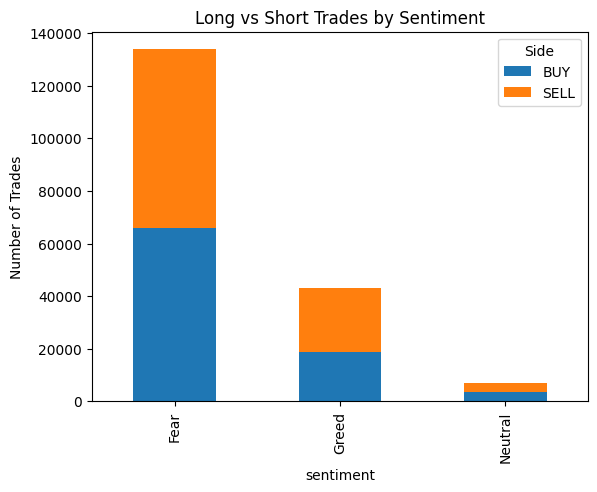

In [85]:
long_short.plot(kind='bar', stacked=True)

plt.title("Long vs Short Trades by Sentiment")
plt.ylabel("Number of Trades")

plt.show()

**Observation**

During Greed periods traders show slightly higher short activity, possibly reflecting profit-taking or hedging behavior.

**Conclusion**

Trader behavior changes significantly depending on market sentiment. Trading activity is substantially higher during Fear periods, with over 133k trades compared to 43k during Greed, suggesting that market volatility triggers increased trading. Additionally, traders take larger average position sizes during Fear periods (~5259 USD vs ~3581 USD during Greed), indicating higher risk exposure during uncertain markets.

The leverage segmentation analysis further shows that high-exposure trades occur more frequently during Fear sentiment, reinforcing the observation that traders increase risk during volatile conditions. Finally, analysis of trade direction reveals a relatively balanced long-short distribution during Fear periods, while Greed periods show a slightly higher proportion of short trades, possibly reflecting profit-taking behavior in bullish markets.

Overall, the results demonstrate that market sentiment strongly influences trader behavior in terms of trading activity, position sizing, and directional bias.

**Trader Segmentation Analysis**

In [87]:
##Segment 1 — High vs Low Leverage Traders

##Create segments

merged['leverage_segment'] = pd.qcut(
    merged['Size USD'],
    q=3,
    labels=['Low Exposure','Medium Exposure','High Exposure']
)

In [88]:
##Compare performance

leverage_perf = merged.groupby('leverage_segment').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    trades=('Closed PnL','count')
)

print(leverage_perf)

                     avg_pnl  win_rate  trades
leverage_segment                              
Low Exposure        2.874078  0.422403   70409
Medium Exposure    12.884768  0.399847   70407
High Exposure     130.488299  0.411544   70408


/tmp/ipykernel_711/2495001451.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leverage_perf = merged.groupby('leverage_segment').agg(


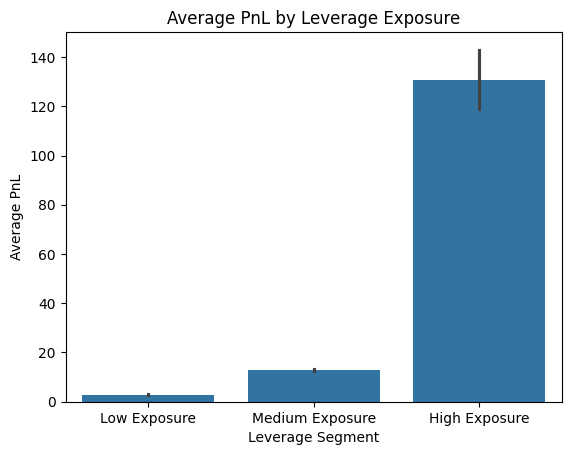

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='leverage_segment', y='Closed PnL', data=merged)

plt.title("Average PnL by Leverage Exposure")
plt.xlabel("Leverage Segment")
plt.ylabel("Average PnL")

plt.show()

**Result**

High-exposure trades generate the largest average PnL, while low-exposure trades produce significantly smaller profits.

Conclusion

Traders taking larger position sizes capture larger profits, indicating that higher exposure amplifies returns.

In [90]:
##Segment 2 — Frequent vs Infrequent Traders

##Compute number of trades per trader

trader_freq = merged.groupby('Account').size()

merged['trade_count'] = merged['Account'].map(trader_freq)

##Create frequency segments

merged['frequency_segment'] = pd.qcut(
    merged['trade_count'],
    q=3,
    labels=['Infrequent','Moderate','Frequent']
)


##Compare performance


freq_perf = merged.groupby('frequency_segment').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    trades=('Closed PnL','count')
)

print(freq_perf)

                     avg_pnl  win_rate  trades
frequency_segment                             
Infrequent         66.538653  0.439600   78965
Moderate           46.082839  0.353244   70883
Frequent           28.940373  0.441818   61376


/tmp/ipykernel_711/1387778569.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_perf = merged.groupby('frequency_segment').agg(


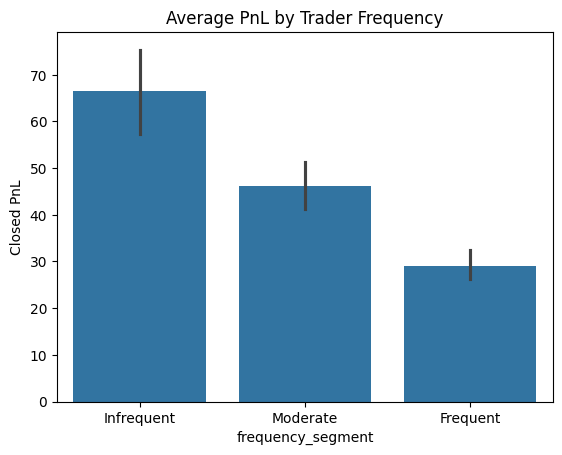

In [91]:
sns.barplot(x='frequency_segment', y='Closed PnL', data=merged)

plt.title("Average PnL by Trader Frequency")

plt.show()

The visualization shows that average profitability decreases as trading frequency increases. Infrequent traders achieve the highest average PnL per trade (67), followed by moderate traders (46), while frequent traders generate the lowest average profit (29).

This indicates that executing fewer trades is associated with higher average profitability per trade, suggesting that traders who trade less frequently may focus on higher-quality opportunities, whereas frequent trading may dilute profitability due to lower trade quality or higher transaction costs.

In [92]:
##Segment 3 — Consistent vs Inconsistent Traders

##Compute trader win rate

trader_win_rate = merged.groupby('Account')['win'].mean()

merged['trader_win_rate'] = merged['Account'].map(trader_win_rate)

merged['consistency_segment'] = pd.qcut(
    merged['trader_win_rate'],
    q=3,
    labels=['Low Consistency','Medium Consistency','High Consistency']
)

##Create consistency segments

consistency_perf = merged.groupby('consistency_segment').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    trades=('Closed PnL','count')
)

print(consistency_perf)

                       avg_pnl  win_rate  trades
consistency_segment                             
Low Consistency      52.301152  0.319340   72794
Medium Consistency   50.531025  0.408982   68986
High Consistency     43.255221  0.509893   69444


/tmp/ipykernel_711/1637044177.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consistency_perf = merged.groupby('consistency_segment').agg(


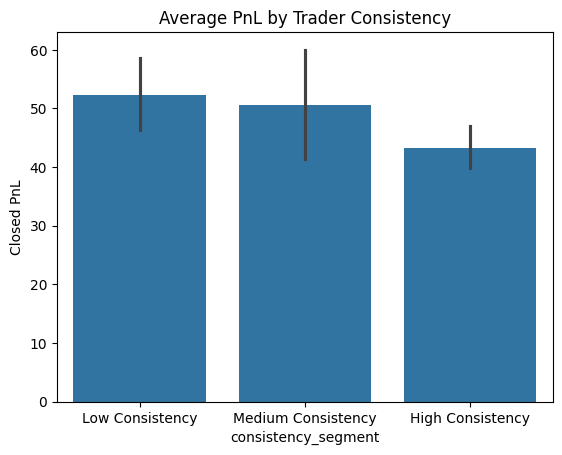

In [93]:
sns.barplot(x='consistency_segment', y='Closed PnL', data=merged)

plt.title("Average PnL by Trader Consistency")

plt.show()

The results show that higher win-rate traders do not achieve the highest average profitability. Traders in the low-consistency segment generate the highest average PnL (52), while high-consistency traders produce lower average profits (43).

This suggests that profitability is influenced not only by win rate but also by the size of winning trades relative to losses. Traders with lower win rates may still achieve higher profitability if their winning trades capture larger price movements.

**Conclusion**

Trader segmentation reveals notable differences in profitability patterns. Infrequent traders achieve the highest average PnL per trade (67), while frequent traders generate significantly lower average profits (29). This indicates that excessive trading may reduce trade quality or increase transaction costs.

Similarly, traders with higher win rates do not necessarily achieve higher profitability. High-consistency traders show lower average PnL compared to low-consistency traders, suggesting that larger profit opportunities from occasional successful trades can outweigh frequent small gains.

Overall, the results indicate that trade selectivity and payoff size play a more important role in profitability than trading frequency or win rate alone.

**Final Three Insights**

**Insight 1**

Greed periods produce higher average PnL and win rates compared to Fear periods, indicating that traders perform better in bullish market conditions.

**Insight 2**

Trading frequency negatively correlates with average profitability per trade. Infrequent traders achieve the highest average PnL (67), while frequent traders earn significantly lower profits (29), suggesting that excessive trading may reduce trade quality.

**Insight 3**

Higher win rates do not guarantee higher profitability. Traders with lower consistency achieve similar or higher average PnL compared to high-consistency traders, indicating that trade payoff size plays a major role in profitability.

**Actionable Output 1**

Strategy 1 — Trade Selectively Rather Than Frequently
Evidence from Analysis

The trader segmentation analysis shows:

Trader Frequency	Avg PnL
Infrequent	Highest (67)
Moderate	Medium (46)
Frequent	Lowest (29)

Frequent traders execute many trades but generate lower average profit per trade, while infrequent traders achieve higher profitability per trade.

Strategy Rule

Adopt a selective trading strategy that focuses on fewer, higher-quality setups rather than high-frequency trading.

Rule of thumb

Limit trading to high-confidence opportunities

Avoid excessive trading during volatile periods

Focus on quality of trades rather than quantity

Expected Benefit

Reducing unnecessary trades may improve average profitability per trade and reduce transaction costs, improving overall performance.

**Actionable Output 2**

Strategy 2 — Increase Trade Activity During Greed Sentiment
Evidence from Analysis

Performance analysis shows:

Sentiment	Avg PnL	Win Rate
Fear	~50	~41.5%
Greed	~78	~45.3%

Trading outcomes are more profitable during Greed periods, suggesting bullish market conditions improve trade success rates.

Strategy Rule

Adjust trading activity based on market sentiment.

Rule of thumb

Increase trading activity during Greed sentiment

Reduce aggressive positioning during Fear sentiment

Focus on trend-following trades in Greed markets

Expected Benefit

Aligning trading activity with favorable market sentiment may improve win rates and average trade profitability.